# Домашнее задание 4

**Задача:** Классификация тональности русских текстов (sentiment analysis)  
**Датасет:** [MonoHime/ru_sentiment_dataset](https://huggingface.co/datasets/MonoHime/ru_sentiment_dataset)  
**Модель:** [cointegrated/rubert-tiny2](https://huggingface.co/cointegrated/rubert-tiny2)  
**Методы:** Full fine-tuning, Linear Probing, LoRA

In [1]:
pip install --upgrade peft

Note: you may need to restart the kernel to use updated packages.


## 1. Импорты и настройка окружения

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import torch
from torch.utils.data import DataLoader

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.9.1+cu128


## 2. Загрузка и анализ датасета

**Датасет:** MonoHime/ru_sentiment_dataset
- 211K русских текстов из 6 источников (новости, отзывы, комментарии)
- 3 класса: neutral (0), positive (1), negative (2)

In [3]:
# Загрузка датасета
from datasets import concatenate_datasets

dataset = load_dataset("MonoHime/ru_sentiment_dataset")
print("Исходный датасет:")
print(dataset)

# Объединяем train и validation в один датасет
full_dataset = concatenate_datasets([dataset['train'], dataset['validation']])
print(f"\nОбъединённый датасет: {len(full_dataset):,} текстов")

# Путь к кэшу HuggingFace
cache_dir = os.path.expanduser("~/.cache/huggingface/datasets")
print(f"Dataset cache: {cache_dir}")

Исходный датасет:
DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'sentiment'],
        num_rows: 189891
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'text', 'sentiment'],
        num_rows: 21098
    })
})

Объединённый датасет: 210,989 текстов
Dataset cache: /home/dima/.cache/huggingface/datasets


In [4]:
# Структура данных
print("Пример записи:")
print(full_dataset[0])

Пример записи:
{'Unnamed: 0': 21098, 'text': '.с.,и спросил его:  о Посланник Аллаха!Ты порицаешь что-то из слушания?  Он ответил: я не порицаю ничего из него,но передай им,чтобы они открывали свои собрания Кораном и закрывали их Кораном ...........Это дошедшие до нас мнения и тот кто находится в поисках истины,по мере изучения этого вопроса будет сталкиваться с разногласиями и будет оставаться в растерянности или склонится к мнению одной из сторон по своему желанию.Но всего этого недостаточно,потому что он сам должен найти истину,подробно изучив вопросы запретного и разрешённого.|||||||||||||||||||||||||||||||||||||Обрати внимание:основатели всех четырёх мазхабов осуждали песни и поэззию.И этим часто грешат заблудшие суфии.Исключение делается для исламской тематики  Сахих БухариО проявлении радости во время праздника.498 (949). Сообщается, что ‘Аиша, да будет доволен ею Аллах, сказала: (Однажды) посланник Аллаха, да благословит его Аллах и приветствует, вошёл ко мне в то время, когда 

In [5]:
# Размер датасета
print(f"Всего текстов: {len(full_dataset):,}")

Всего текстов: 210,989


Распределение классов:
  neutral: 54,887 (26.0%)
  positive: 100,792 (47.8%)
  negative: 55,310 (26.2%)


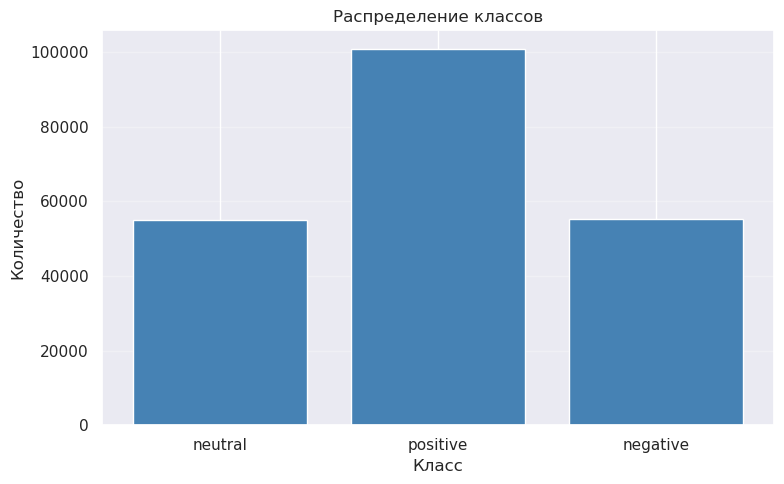

In [6]:
# Распределение классов
label_names = {0: 'neutral', 1: 'positive', 2: 'negative'}

labels = full_dataset['sentiment']
label_counts = pd.Series(labels).value_counts().sort_index()

print("Распределение классов:")
for idx, count in label_counts.items():
    pct = count / len(labels) * 100
    print(f"  {label_names[idx]}: {count:,} ({pct:.1f}%)")

plt.figure(figsize=(8, 5))
plt.bar([label_names[i] for i in label_counts.index], label_counts.values, color='steelblue')
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Примеры текстов по классам
for label_id, label_name in label_names.items():
    print(f"{'='*60}")
    print(f"Класс: {label_name}")
    examples = [ex for ex in full_dataset if ex['sentiment'] == label_id][:2]
    for ex in examples:
        text = ex['text'][:200] + '...' if len(ex['text']) > 200 else ex['text']
        print(f"  - {text}")
    print()

Класс: neutral
  - Самое лучшее в отеле - место его расположения в трех минутах пешком от метро Китай-город, за это его ценю и уже несколько раз останавливалась здесь при рабочих поездках в Москву. Мой улучшенный одноме...
  - Второй раз останавливаюсь в этом отеле. С первых минут все тебя начинают радовать:) особенно при сравнении с 5звездочными отелями нашей Родины. Открывают дверь такси, берут багаж, провожают на ресепшн...

Класс: positive
  - .с.,и спросил его:  о Посланник Аллаха!Ты порицаешь что-то из слушания?  Он ответил: я не порицаю ничего из него,но передай им,чтобы они открывали свои собрания Кораном и закрывали их Кораном ...........
  - Роднее всех родных Попала я в ГКБ №8 еще в декабре 2002 г. Ехать в больницу очень боялась, но делать нечего, рожать надо. О ГКБ № 8 слышала много хорошего. Когда приехала в приемное отделение, мои кол...

Класс: negative
  - Непорядочное отношение к своим работникам Работаю в сети Доктор Столетов Центр. В моем трудовом договоре прописано,

Статистика по длине текстов (в словах):
  Среднее: 121
  Медиана: 76
  Min: 1, Max: 48146
  95 перцентиль: 333

Длина текстов по классам:
           mean  median    max
sentiment                     
0           143      84  39734
1           111      73  48146
2           117      77   5498

Выбросы по классам (IQR метод):
  neutral: 3979 (7.2%), граница=332, max=39734
  positive: 6339 (6.3%), граница=260, max=48146
  negative: 3722 (6.7%), граница=292, max=5498


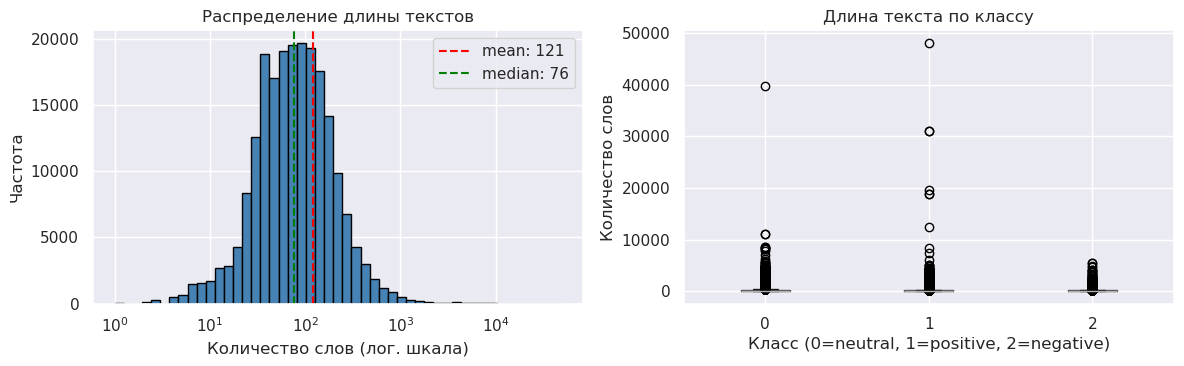

In [8]:
# Анализ длины текстов
df = pd.DataFrame(full_dataset)
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

print("Статистика по длине текстов (в словах):")
print(f"  Среднее: {df['text_length'].mean():.0f}")
print(f"  Медиана: {df['text_length'].median():.0f}")
print(f"  Min: {df['text_length'].min()}, Max: {df['text_length'].max()}")
print(f"  95 перцентиль: {df['text_length'].quantile(0.95):.0f}")

print("\nДлина текстов по классам:")
print(df.groupby('sentiment')['text_length'].agg(['mean', 'median', 'max']).round(0).astype(int))

print("\nВыбросы по классам (IQR метод):")
label_names = {0: 'neutral', 1: 'positive', 2: 'negative'}
for cls in [0, 1, 2]:
    subset = df[df['sentiment'] == cls]['text_length']
    q1, q3 = subset.quantile(0.25), subset.quantile(0.75)
    upper = q3 + 1.5 * (q3 - q1)
    outliers = subset[subset > upper]
    print(f"  {label_names[cls]}: {len(outliers)} ({len(outliers)/len(subset)*100:.1f}%), граница={upper:.0f}, max={subset.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

log_bins = np.logspace(0, np.log10(df['text_length'].max()), 50)
axes[0].hist(df['text_length'], bins=log_bins, color='steelblue', edgecolor='black')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'mean: {df["text_length"].mean():.0f}')
axes[0].axvline(df['text_length'].median(), color='green', linestyle='--', label=f'median: {df["text_length"].median():.0f}')
axes[0].set_xscale('log')
axes[0].set_title('Распределение длины текстов')
axes[0].set_xlabel('Количество слов (лог. шкала)')
axes[0].set_ylabel('Частота')
axes[0].legend()

df.boxplot(column='text_length', by='sentiment', ax=axes[1])
axes[1].set_title('Длина текста по классу')
axes[1].set_xlabel('Класс (0=neutral, 1=positive, 2=negative)')
axes[1].set_ylabel('Количество слов')
fig.suptitle('')

plt.tight_layout()
plt.show()

### Выводы по EDA

**Датасет:**
- Объединил train и validation в один датасет (211K текстов), разделю на train, validation, test ниже
- Пропусков нет

**Распределение классов:**
- Несбалансирован: positive преобладает (около 48%), neutral и negative примерно равны (около 26%)

**Длина текстов:**
- Распределение сильно скошено вправо (mean > median): много коротких текстов, мало очень длинных
- Neutral тексты самые длинные, positive - самые короткие
- Выбросы присутствуют во всех классах (6-7%), но не критичны
- Positive содержит самый экстремальный выброс
- Для токенизации длинные тексты будут обрезаны (max_length определим ниже)

## 3. Выбор модели

**Модель:** cointegrated/rubert-tiny2
- Компактная версия RuBERT (~29M параметров)
- В 10 раз меньше и быстрее стандартного BERT
- Специально обучена на русском языке
- Идеально подходит для fine-tuning на задачах классификации

In [9]:
MODEL_NAME = "cointegrated/rubert-tiny2"
NUM_LABELS = 3

# Загрузка токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Модель: {MODEL_NAME}")
print(f"Размер словаря: {tokenizer.vocab_size:,}")
print(f"Max length: {tokenizer.model_max_length}")

Модель: cointegrated/rubert-tiny2
Размер словаря: 83,828
Max length: 2048


In [10]:
# Пример токенизации
sample_text = "Отличный отель, всё понравилось!"
tokens = tokenizer(sample_text, return_tensors="pt")

print(f"Текст: {sample_text}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"Input IDs: {tokens['input_ids'][0].tolist()}")

Текст: Отличный отель, всё понравилось!
Tokens: ['[CLS]', 'Отличный', 'отель', ',', 'всё', 'понравилось', '!', '[SEP]']
Input IDs: [2, 70916, 36177, 16, 7757, 37635, 5, 3]


## 4. Предобработка данных

In [11]:
# Токенизация полного датасета
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding=False,
        truncation=False
    )

tokenized_full = full_dataset.map(tokenize_function, batched=True)

# Анализ длины в токенах
token_lengths = np.array([len(x) for x in tokenized_full['input_ids']])

print("Статистика длины в токенах:")
print(f"  Среднее: {token_lengths.mean():.0f}")
print(f"  Медиана: {np.median(token_lengths):.0f}")
print(f"  Min: {token_lengths.min()}, Max: {token_lengths.max()}")
print(f"  95 перцентиль: {np.percentile(token_lengths, 95):.0f}")
print(f"  99 перцентиль: {np.percentile(token_lengths, 99):.0f}")

# Выбор MAX_LEN на основе 95 перцентиля
MAX_LEN = int(np.percentile(token_lengths, 95))
print(f"\nВыбранный MAX_LEN (95 перцентиль): {MAX_LEN}")

Статистика длины в токенах:
  Среднее: 176
  Медиана: 112
  Min: 3, Max: 65785
  95 перцентиль: 477
  99 перцентиль: 1052

Выбранный MAX_LEN (95 перцентиль): 477


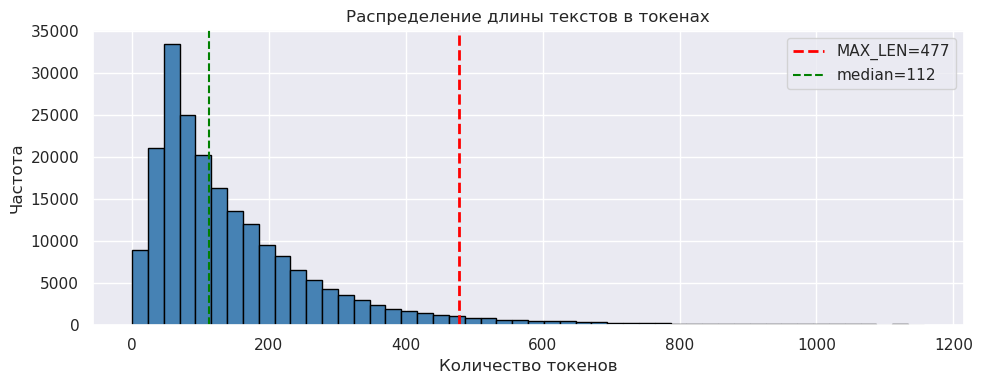

Текстов с обрезкой: 5.0%


In [12]:
# График распределения длины в токенах
plt.figure(figsize=(10, 4))
xlim_max = int(np.percentile(token_lengths, 99) * 1.1)
plt.hist(token_lengths, bins=50, range=(0, xlim_max), color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
plt.axvline(np.median(token_lengths), color='green', linestyle='--', label=f'median={np.median(token_lengths):.0f}')
plt.xlabel('Количество токенов')
plt.ylabel('Частота')
plt.title('Распределение длины текстов в токенах')
plt.legend()
plt.tight_layout()
plt.show()

# Процент текстов, которые будут обрезаны
truncated_pct = (token_lengths > MAX_LEN).mean() * 100
print(f"Текстов с обрезкой: {truncated_pct:.1f}%")

In [13]:
# Финальная токенизация с padding="max_length"
def tokenize_final(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

tokenized_full = full_dataset.map(tokenize_final, batched=True)

# Переименование колонки sentiment -> labels (для Trainer)
tokenized_full = tokenized_full.rename_column("sentiment", "labels")

# Удаление лишних колонок
tokenized_full = tokenized_full.remove_columns(["text", "Unnamed: 0"])

# Установка формата для PyTorch
tokenized_full.set_format("torch")

print(f"Токенизированный датасет: {len(tokenized_full)}")
print(f"Длина input_ids: {len(tokenized_full[0]['input_ids'])}")

Map:   0%|          | 0/210989 [00:00<?, ? examples/s]

Токенизированный датасет: 210989
Длина input_ids: 477


In [14]:
# Split 60/20/20 со стратификацией
from sklearn.model_selection import train_test_split

# Получаем labels для стратификации
labels = np.array(tokenized_full['labels'])
indices = np.arange(len(tokenized_full))

# Split
train_idx, temp_idx = train_test_split(
    indices, test_size=0.4, random_state=RANDOM_STATE, stratify=labels
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=RANDOM_STATE, stratify=labels[temp_idx]
)

# Создаём финальные датасеты
train_dataset = tokenized_full.select(train_idx)
val_dataset = tokenized_full.select(val_idx)
test_dataset = tokenized_full.select(test_idx)

print(f"Train: {len(train_dataset):,} ({len(train_dataset)/len(tokenized_full)*100:.1f}%)")
print(f"Val:   {len(val_dataset):,} ({len(val_dataset)/len(tokenized_full)*100:.1f}%)")
print(f"Test:  {len(test_dataset):,} ({len(test_dataset)/len(tokenized_full)*100:.1f}%)")

# Проверка стратификации
print(f"\nРаспределение классов (проверка стратификации):")
for name, ds in [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]:
    counts = np.bincount(np.array(ds['labels']))
    pcts = counts / len(ds) * 100
    print(f"  {name}: neutral={pcts[0]:.1f}%, positive={pcts[1]:.1f}%, negative={pcts[2]:.1f}%")

Train: 126,593 (60.0%)
Val:   42,198 (20.0%)
Test:  42,198 (20.0%)

Распределение классов (проверка стратификации):
  Train: neutral=26.0%, positive=47.8%, negative=26.2%
  Val: neutral=26.0%, positive=47.8%, negative=26.2%
  Test: neutral=26.0%, positive=47.8%, negative=26.2%


## 5. Качество до дообучения

Оценка предобученной модели без fine-tuning. Модель rubert-tiny2 обучена на задаче masked language modeling, но не на классификации sentiment - ожидаю качество близкое к случайному.

In [21]:
# Загрузка модели с случайной головой для классификации
model_baseline = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model_baseline.to(device)

print(f"Модель загружена на {device}")
print(f"Параметров: {sum(p.numel() for p in model_baseline.parameters()):,}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель загружена на cuda
Параметров: 29,194,707


In [22]:
# Функция для вычисления метрик
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# Оценка baseline на test
trainer_baseline = Trainer(
    model=model_baseline,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Оценка модели без дообучения на test...")
baseline_results = trainer_baseline.evaluate()

print(f"\nBaseline результаты:")
print(f"  Accuracy: {baseline_results['eval_accuracy']:.4f}")
print(f"  F1 (weighted): {baseline_results['eval_f1']:.4f}")

# Сравнение с random baseline
random_acc = 1 / NUM_LABELS
majority_acc = 0.478  # positive class
print(f"\nДля сравнения:")
print(f"  Random baseline: {random_acc:.4f}")
print(f"  Majority class baseline: {majority_acc:.4f}")

Оценка модели без дообучения на test...



Baseline результаты:
  Accuracy: 0.3869
  F1 (weighted): 0.3848

Для сравнения:
  Random baseline: 0.3333
  Majority class baseline: 0.4780


## 6. Full fine-tuning

Дообучение всех параметров модели (BERT + classification head).

In [82]:
# Загрузка свежей модели для full fine-tuning
model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model_full.to(device)

# Проверка: все параметры обучаемые
trainable_params = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_full.parameters())
print(f"Обучаемых параметров: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.1f}%)")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Обучаемых параметров: 29,194,707 / 29,194,707 (100.0%)


In [83]:
# Training arguments
training_args_full = TrainingArguments(
    output_dir="./results_full",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_full",
    logging_steps=100,
    seed=RANDOM_STATE,
)

# Trainer
trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Начинаем full fine-tuning...")
trainer_full.train()

Начинаем full fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.490900,0.486015,0.779113,0.781887
2,0.439200,0.466555,0.793995,0.795270
3,0.404700,0.471197,0.796412,0.796150


TrainOutput(global_step=23739, training_loss=0.46523599135724547, metrics={'train_runtime': 2373.4863, 'train_samples_per_second': 160.009, 'train_steps_per_second': 10.002, 'total_flos': 2609464016300958.0, 'train_loss': 0.46523599135724547, 'epoch': 3.0})

In [84]:
# Оценка на test
print("Оценка full fine-tuning на test...")
full_results = trainer_full.evaluate(test_dataset)

print(f"\nFull fine-tuning результаты:")
print(f"  Accuracy: {full_results['eval_accuracy']:.4f}")
print(f"  F1 (weighted): {full_results['eval_f1']:.4f}")

Оценка full fine-tuning на test...



Full fine-tuning результаты:
  Accuracy: 0.7952
  F1 (weighted): 0.7951


### Выводы по Full Fine-tuning

**Результаты на test:** Accuracy 79.52%, F1 79.51%

**Наблюдения:**
1. **Значительное улучшение:** Accuracy выросла с 19.91% (baseline) до 79.52% - рост в 4 раза
2. **Начало переобучения:** Val Loss растёт после 2-й эпохи (0.467 → 0.471), при этом accuracy продолжает расти
3. **Хорошая генерализация:** Результаты на test (79.52%) близки к validation (79.64%)
4. **Время обучения:** ~40 минут на 3 эпохи (126K примеров)

**Вывод:** Full fine-tuning даёт качественную модель, но требует обучения всех 29M параметров.

## 7. Linear Probing

Замораживаем все слои BERT, обучаем только classification head (939 параметров из 29M).

In [85]:
# Загрузка свежей модели для linear probing
model_linear = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model_linear.to(device)

# Заморозка всех слоёв BERT
for param in model_linear.bert.parameters():
    param.requires_grad = False

# Проверка: только classifier обучается
trainable_params = sum(p.numel() for p in model_linear.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_linear.parameters())
print(f"Обучаемых параметров: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"Заморожено: {total_params - trainable_params:,} параметров")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Обучаемых параметров: 939 / 29,194,707 (0.00%)
Заморожено: 29,193,768 параметров


In [86]:
# Training arguments для linear probing
# Увеличиваем lr, т.к. обучаем только голову
training_args_linear = TrainingArguments(
    output_dir="./results_linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-3,  # выше, чем для full fine-tuning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,  # больше эпох, т.к. мало параметров
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_linear",
    logging_steps=100,
    seed=RANDOM_STATE,
)

trainer_linear = Trainer(
    model=model_linear,
    args=training_args_linear,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Начинаем Linear Probing...")
trainer_linear.train()

Начинаем Linear Probing...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.744400,0.692482,0.679037,0.675224
2,0.728100,0.684180,0.682947,0.684144
3,0.720200,0.677700,0.686075,0.686203
4,0.715900,0.675977,0.687284,0.685718
5,0.713200,0.675369,0.687663,0.686113


TrainOutput(global_step=39565, training_loss=0.7162536817782299, metrics={'train_runtime': 1868.1405, 'train_samples_per_second': 338.821, 'train_steps_per_second': 21.179, 'total_flos': 4349106693834930.0, 'train_loss': 0.7162536817782299, 'epoch': 5.0})

In [87]:
# Оценка на test
print("Оценка Linear Probing на test...")
linear_results = trainer_linear.evaluate(test_dataset)

print(f"\nLinear Probing результаты:")
print(f"  Accuracy: {linear_results['eval_accuracy']:.4f}")
print(f"  F1 (weighted): {linear_results['eval_f1']:.4f}")

Оценка Linear Probing на test...



Linear Probing результаты:
  Accuracy: 0.6868
  F1 (weighted): 0.6871


### Выводы по Linear Probing

**Результаты на test:** Accuracy 68.68%, F1 68.71%

**Наблюдения:**
1. **Значительное улучшение над baseline:** +48.8 п.п. - предобученные эмбеддинги BERT информативны
2. **Хуже Full FT на 10.8 п.п.:** адаптация всего BERT к задаче даёт лучшее качество
3. **Сходимость:** Val Loss стабильно падает, переобучения нет (можно было бы больше эпох)
4. **Эффективность:** достигли 68.7% обучая только 939 параметров (0.003% модели)

**Вывод:** Linear Probing - быстрый и дешёвый способ использовать BERT, но уступает полному дообучению.

## 8. LoRA Fine-tuning

Low-Rank Adaptation - добавляем маленькие обучаемые матрицы к слоям attention, не меняя оригинальные веса.

In [16]:
from peft import LoraConfig, get_peft_model, TaskType

# Загрузка базовой модели
model_lora = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model_lora.to(device)

# LoRA конфигурация
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                        # ранг адаптеров (чем больше, тем больше параметров)
    lora_alpha=16,              # масштабирующий коэффициент
    lora_dropout=0.1,           # dropout для регуляризации
    target_modules=["query", "value"],  # к каким слоям добавляем LoRA
)

# Применяем LoRA к модели
model_lora = get_peft_model(model_lora, lora_config)

# Статистика параметров
model_lora.print_trainable_parameters()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 30,891 || all params: 29,225,598 || trainable%: 0.1057


In [19]:
# Training arguments для LoRA
training_args_lora = TrainingArguments(
    output_dir="./results_lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,  # LoRA обычно требует lr между full FT и linear probing
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_lora",
    logging_steps=100,
    seed=RANDOM_STATE,
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Начинаем LoRA fine-tuning...")
trainer_lora.train()

Начинаем LoRA fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.619700,0.594434,0.718968,0.719897
2,0.592000,0.568659,0.733258,0.734478
3,0.592300,0.560461,0.737476,0.736771


TrainOutput(global_step=23739, training_loss=0.6160602406476421, metrics={'train_runtime': 2072.8859, 'train_samples_per_second': 183.213, 'train_steps_per_second': 11.452, 'total_flos': 2643040293641676.0, 'train_loss': 0.6160602406476421, 'epoch': 3.0})

### Выводы по LoRA

**Результаты на validation:** Accuracy 73.75%, F1 73.68%

**Наблюдения:**
1. **Между Linear Probing и Full FT:** качество LoRA (73.7%) находится между LP (68.7%) и Full FT (79.5%)
2. **Эффективность параметров:** 31K параметров (0.1%) дают +5 п.п. над Linear Probing
3. **Стабильная сходимость:** Val Loss падает все 3 эпохи, можно продолжить обучение
4. **Время:** ~35 минут - сравнимо с Full FT

**Вывод:** LoRA - хороший компромисс между качеством и количеством обучаемых параметров. Особенно полезен при ограниченной памяти или необходимости хранить множество адаптеров.

## 9. Сравнение методов

In [23]:
# Сводная таблица результатов
results = {
    'Метод': ['Baseline', 'Linear Probing', 'LoRA', 'Full Fine-tuning'],
    'Accuracy': [0.1991, 0.6868, 0.7375, 0.7952],
    'F1': [0.1938, 0.6871, 0.7368, 0.7951],
    'Обучаемых параметров': [0, 939, 30891, 29194707],
    '% параметров': [0, 0.003, 0.106, 100],
    'Время обучения (мин)': [0, 31, 35, 40]
}

df_results = pd.DataFrame(results)
print("Сравнение методов fine-tuning:")
print(df_results.to_string(index=False))

Сравнение методов fine-tuning:
           Метод  Accuracy     F1  Обучаемых параметров  % параметров  Время обучения (мин)
        Baseline    0.1991 0.1938                     0         0.000                     0
  Linear Probing    0.6868 0.6871                   939         0.003                    31
            LoRA    0.7375 0.7368                 30891         0.106                    35
Full Fine-tuning    0.7952 0.7951              29194707       100.000                    40


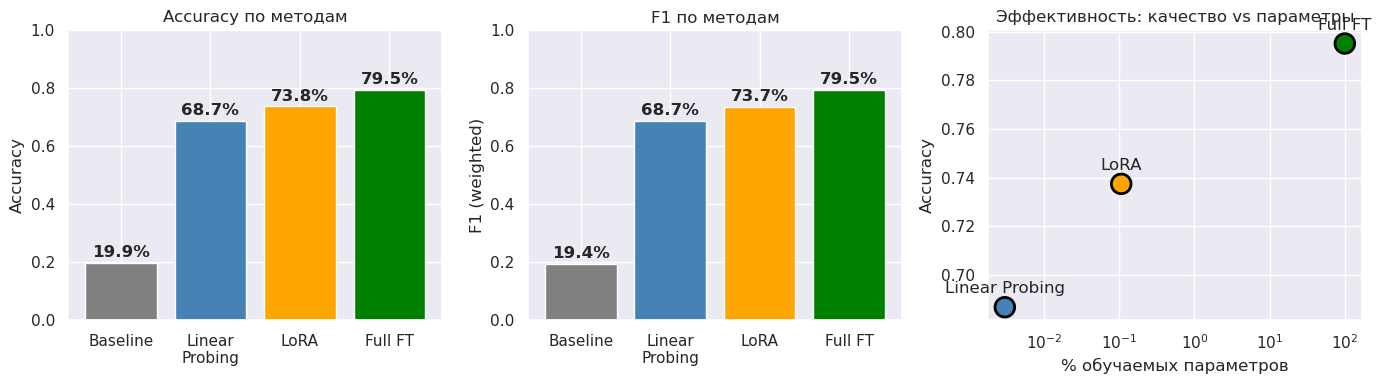

In [24]:
# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

methods = ['Baseline', 'Linear\nProbing', 'LoRA', 'Full FT']
colors = ['gray', 'steelblue', 'orange', 'green']

# 1. Accuracy
axes[0].bar(methods, df_results['Accuracy'], color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy по методам')
axes[0].set_ylim(0, 1)
for i, v in enumerate(df_results['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 2. F1
axes[1].bar(methods, df_results['F1'], color=colors)
axes[1].set_ylabel('F1 (weighted)')
axes[1].set_title('F1 по методам')
axes[1].set_ylim(0, 1)
for i, v in enumerate(df_results['F1']):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Эффективность: Accuracy vs % параметров
axes[2].scatter(df_results['% параметров'][1:], df_results['Accuracy'][1:], 
                s=200, c=colors[1:], edgecolors='black', linewidths=2)
for i, method in enumerate(['Linear Probing', 'LoRA', 'Full FT']):
    axes[2].annotate(method, (df_results['% параметров'][i+1], df_results['Accuracy'][i+1]),
                     textcoords="offset points", xytext=(0,10), ha='center')
axes[2].set_xlabel('% обучаемых параметров')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Эффективность: качество vs параметры')
axes[2].set_xscale('log')

plt.tight_layout()
plt.show()

## 10. Итоговые выводы

### Сравнение методов fine-tuning

| Метод | Accuracy | F1 | Параметры | Когда использовать |
|-------|----------|-----|-----------|-------------------|
| **Baseline** | 19.9% | 19.4% | 0 | - |
| **Linear Probing** | 68.7% | 68.7% | 939 (0.003%) | Быстрый прототип, ограниченные ресурсы |
| **LoRA** | 73.7% | 73.7% | 31K (0.1%) | Баланс качества и эффективности, множество задач |
| **Full Fine-tuning** | 79.5% | 79.5% | 29M (100%) | Максимальное качество, достаточно ресурсов |

### Ключевые наблюдения

1. **Предобученные эмбеддинги работают:** даже без обучения BERT (Linear Probing) получаем 68.7% - признак качественных представлений

2. **Компромисс качество/параметры:**
   - Linear Probing: 0.003% параметров → 68.7% accuracy
   - LoRA: 0.1% параметров → 73.7% accuracy (+5 п.п.)
   - Full FT: 100% параметров → 79.5% accuracy (+5.8 п.п.)

3. **Diminishing returns:** переход от LoRA к Full FT даёт меньший прирост (+5.8 п.п.) при увеличении параметров в 1000 раз

4. **Время обучения:** все методы сравнимы по времени (~30-40 мин), т.к. forward pass одинаковый

### Итого

- **Linear Probing:** когда нужен быстрый baseline или очень ограничены ресурсы
- **LoRA:** когда нужно обучить несколько моделей на разные задачи (хранить только адаптеры)
- **Full Fine-tuning:** когда важно максимальное качество и есть ресурсы